In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Overview
df = pd.read_csv('./examples/2015.csv')
df.shape      # 12 Var, 158 Rows
df.dtypes     # 10 Numeric, 1 Text, 1 Categorical
df.isnull().sum()    # All 0s, no NULL values
df.info()            # memory usage: 14.9+ KB
df.duplicated().sum()   # 0 Duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

np.int64(0)


--- Analysis for: Happiness Score ---
Metric               | Value      | Percentage
---------------------------------------------
Distinct             | 157        | 99.37%
Missing              | 0          | 0.00%
Infinite             | 0          | 0.00%
Zeros                | 0          | 0.00%
Negatives            | 0          | 0.00%
---------------------------------------------
Mean                 | 5.3757
Minimum              | 2.8390
Maximum              | 7.5870
Std Deviation        | 1.1450


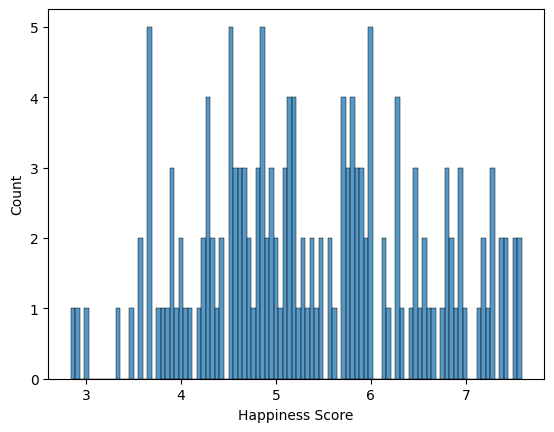

In [23]:
from pandas.api.types import is_numeric_dtype

# Variables
var = input('Enter the name of the variable ')
if var not in df.columns:
    print(f"Error: {var} not found in DataFrame!")
else:
    if is_numeric_dtype(df[var]):
        distinct = df.shape[0] - df[var].duplicated().sum()
        distinct_pst = (distinct/df.shape[0]) * 100
        missing = df[var].isnull().sum()
        missing_pst = (missing/df.shape[0]) * 100
        inf = np.isinf(df[var]).sum()
        inf_pst = (inf/df.shape[0]) * 100
        stats = {
            "Mean": df[var].mean(),
            "Minimum": df[var].min(),
            "Maximum": df[var].max(),
            "Std Deviation": df[var].std()
        }
        zeros = (df[var] == 0).sum()
        zeros_pst = (zeros/df.shape[0]) * 100
        negatives = (df[var] < 0).sum()
        negatives_pst = (negatives/df.shape[0]) * 100
        print(f"\n--- Analysis for: {var} ---")
        if(distinct == df.shape[0]):
            print('Unique')
        print(f"{'Metric':<20} | {'Value':<10} | {'Percentage'}")
        print("-" * 45)
        print(f"{'Distinct':<20} | {distinct:<10} | {distinct_pst:.2f}%")
        print(f"{'Missing':<20} | {missing:<10} | {missing_pst:.2f}%")
        print(f"{'Infinite':<20} | {inf:<10} | {inf_pst:.2f}%")
        print(f"{'Zeros':<20} | {zeros:<10} | {zeros_pst:.2f}%")
        print(f"{'Negatives':<20} | {negatives:<10} | {negatives_pst:.2f}%")
        print("-" * 45)
        for k, v in stats.items():
            print(f"{k:<20} | {v:.4f}")
        sns.histplot(data=df, x=var, bins=100)
    else:
        distinct = df.shape[0] - df[var].duplicated().sum()
        distinct_pst = (distinct/df.shape[0]) * 100
        missing = df[var].isnull().sum()
        missing_pst = (missing/df.shape[0]) * 100
        print(f"{'Metric':<20} | {'Value':<10} | {'Percentage'}")
        print("-" * 45)
        print(f"{'Distinct':<20} | {distinct:<10} | {distinct_pst:.2f}%")
        print(f"{'Missing':<20} | {missing:<10} | {missing_pst:.2f}%")


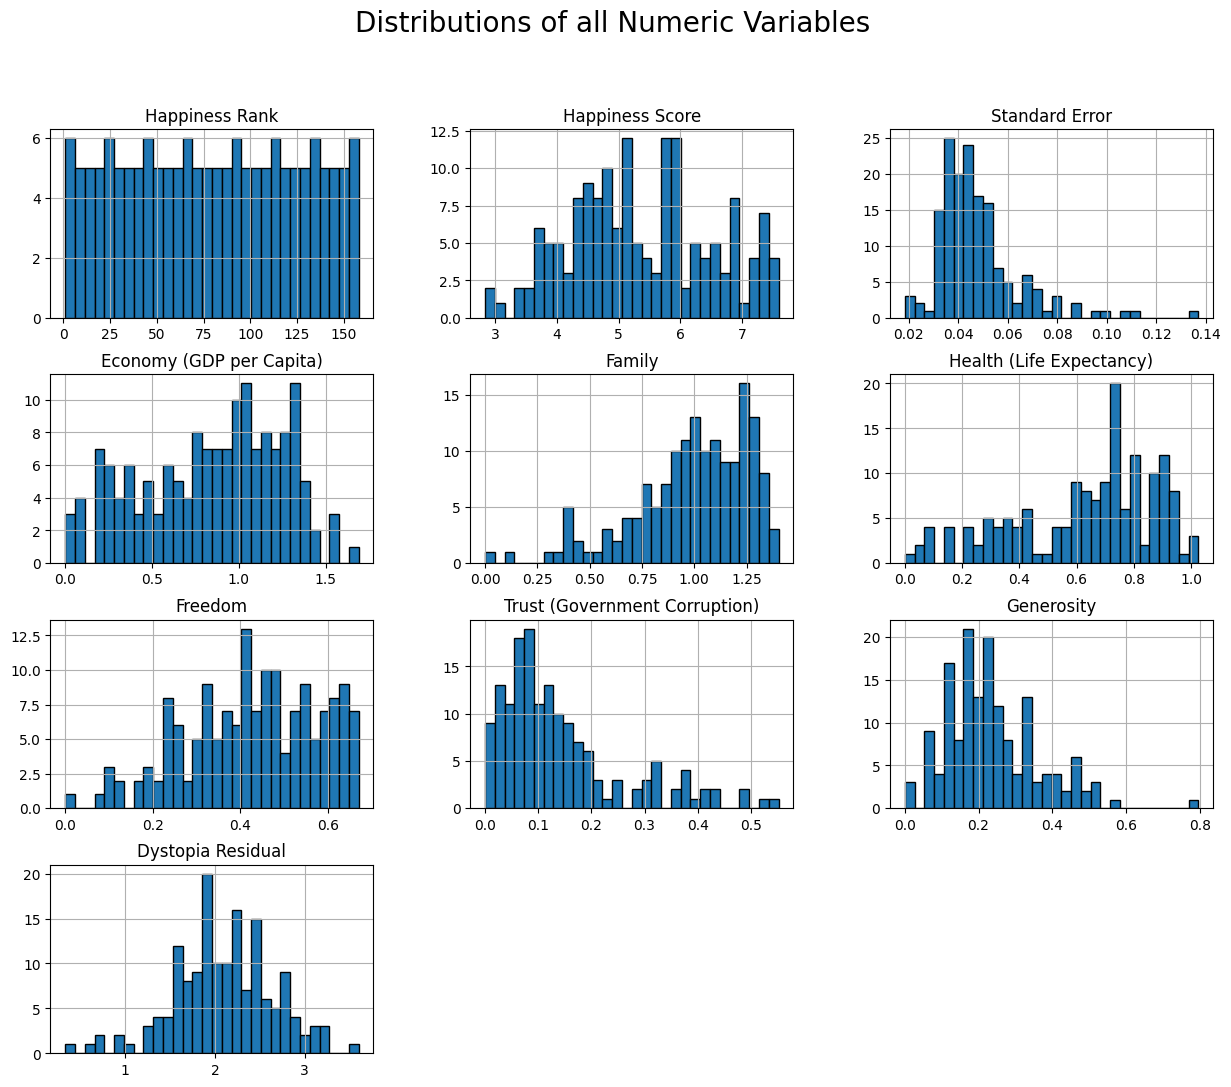

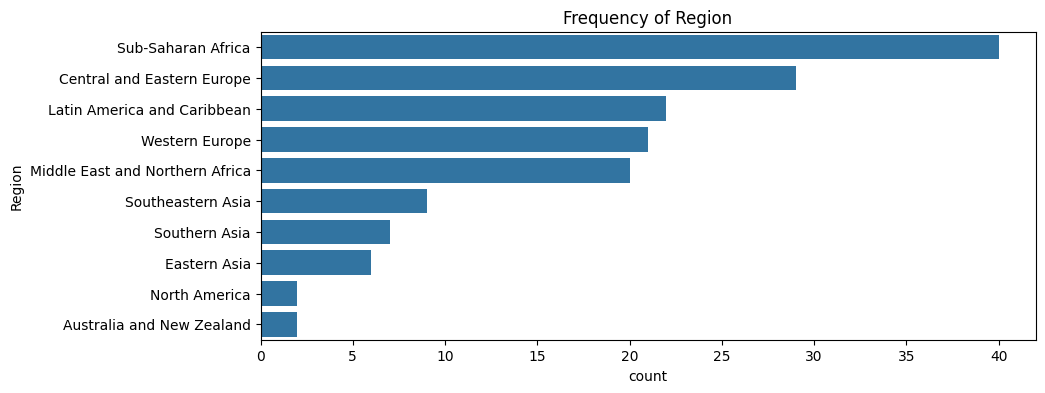

In [26]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Distributions of all Numeric Variables", fontsize=20)

for col in categorical_cols:
    if df[col].nunique() < 15:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f"Frequency of {col}")
        plt.show()

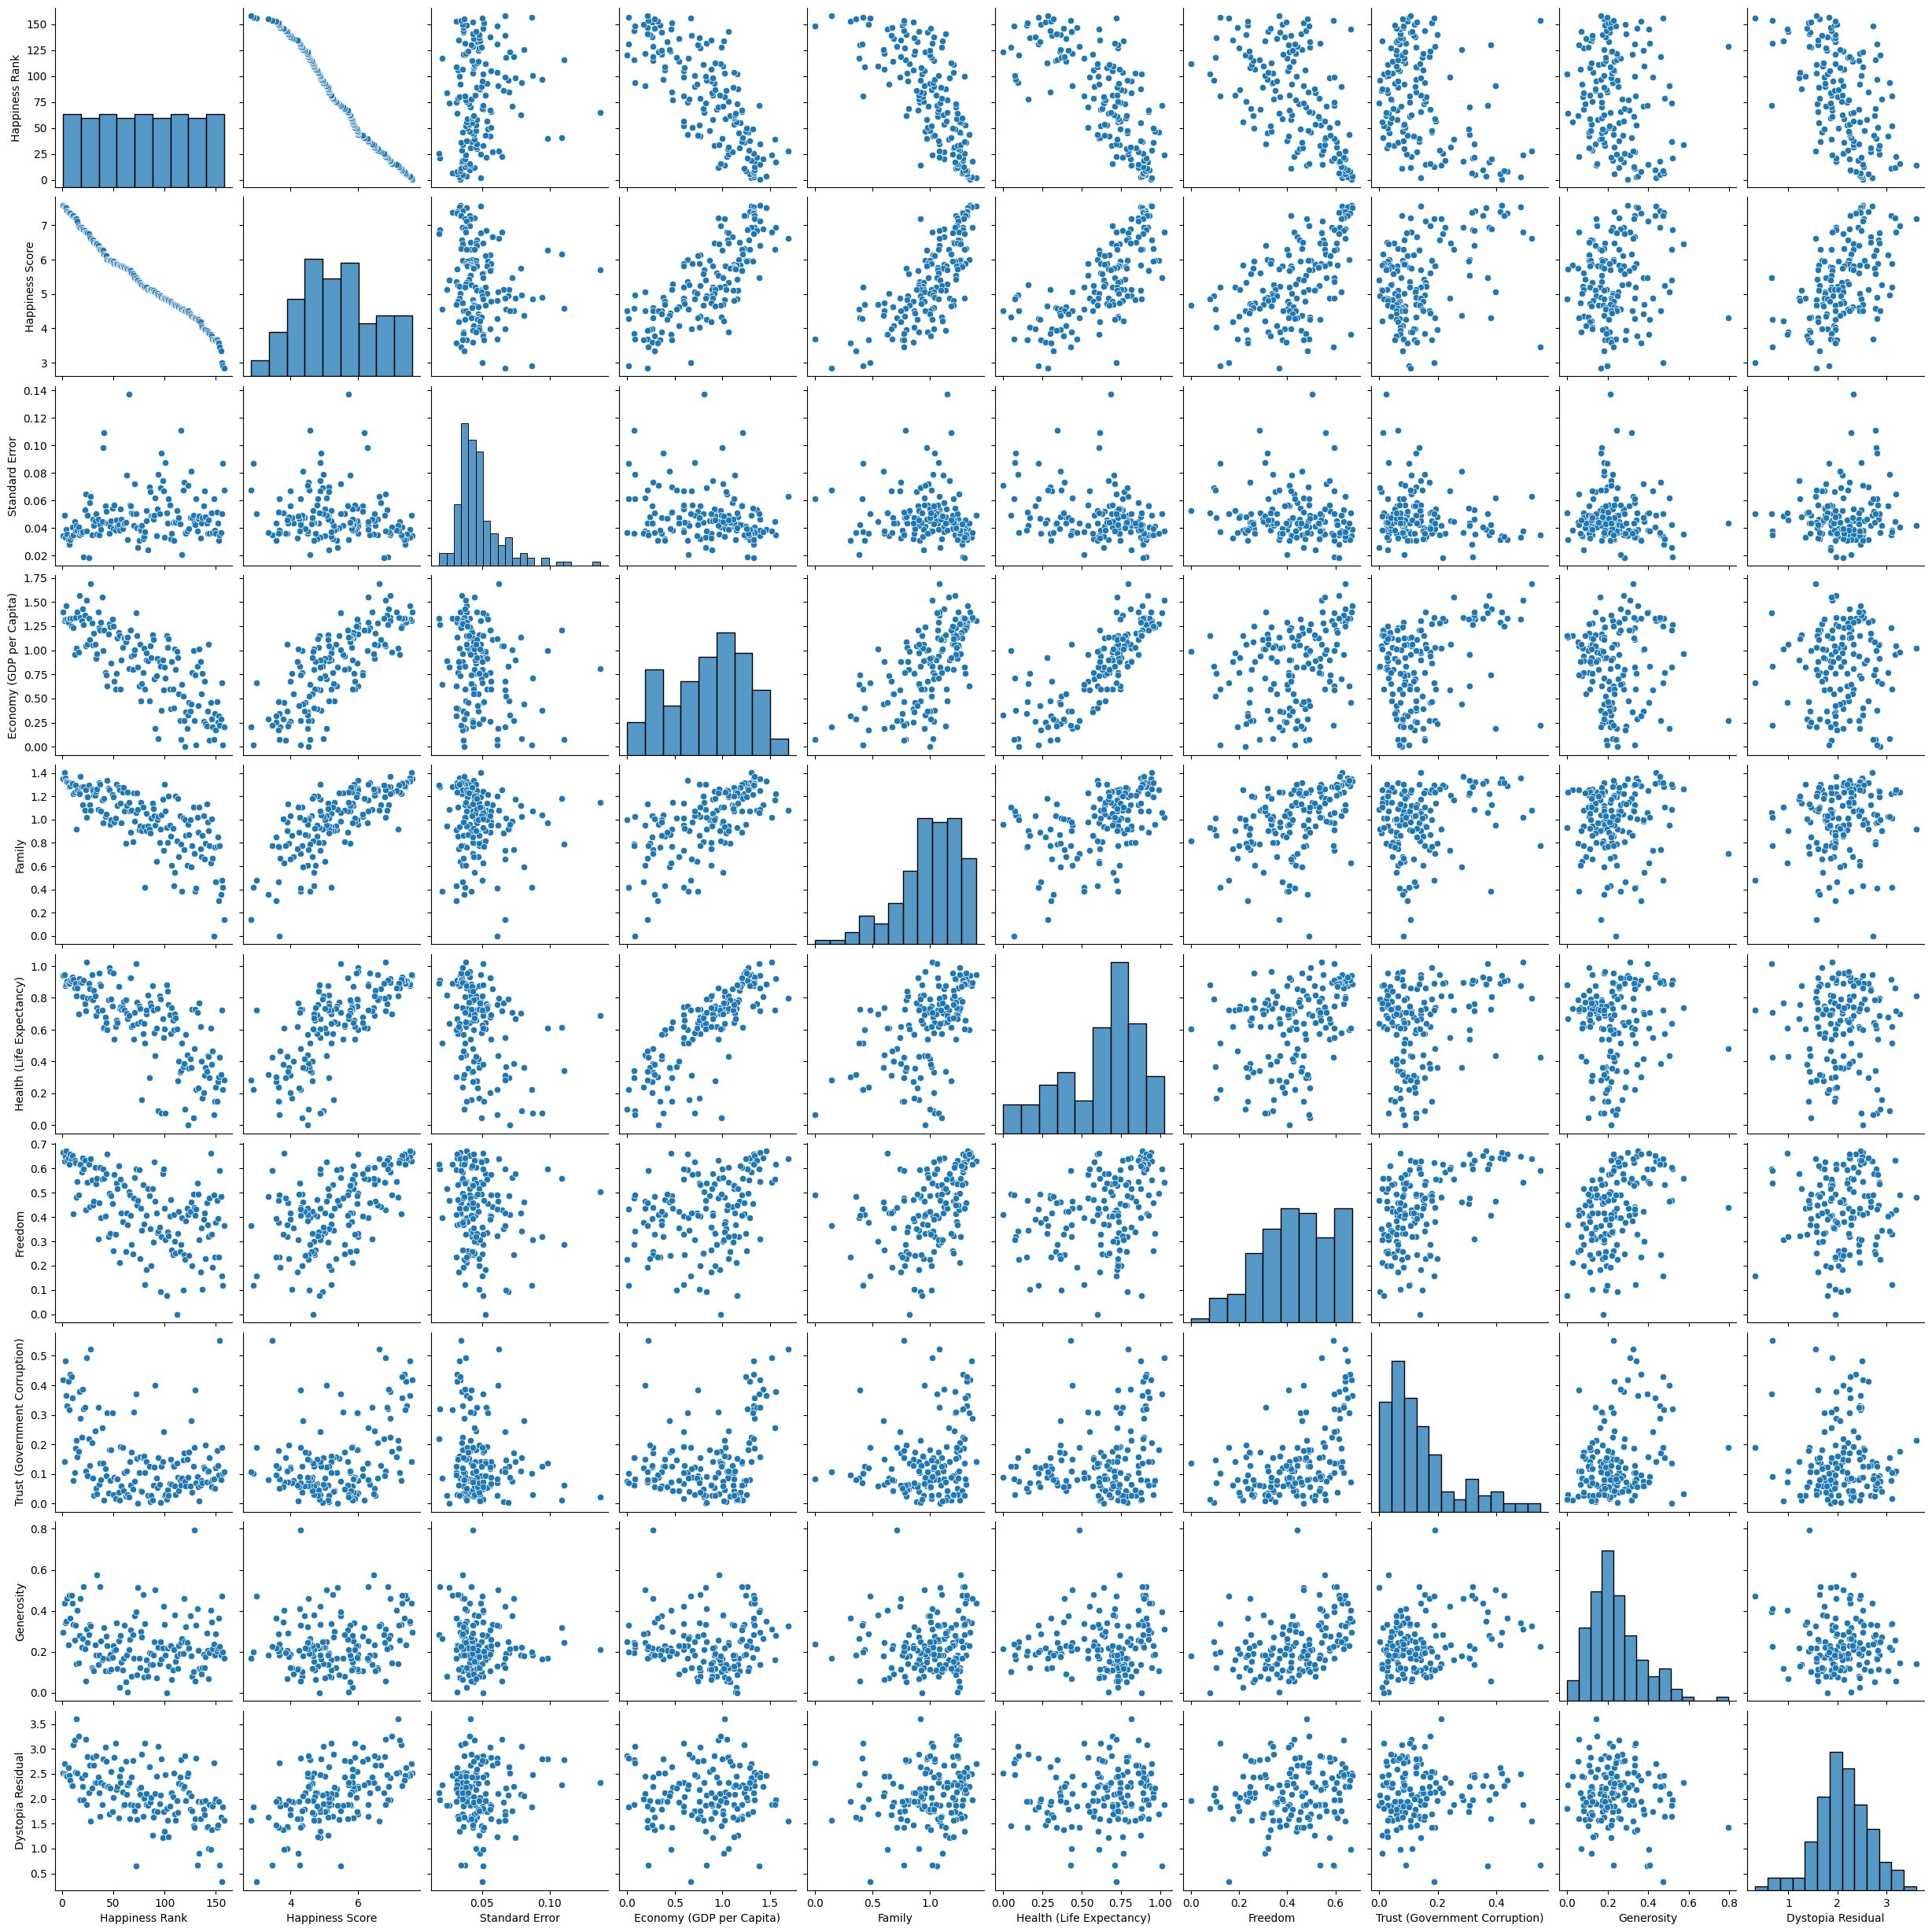

In [39]:
# Interactions
sns.pairplot(df[numeric_cols])

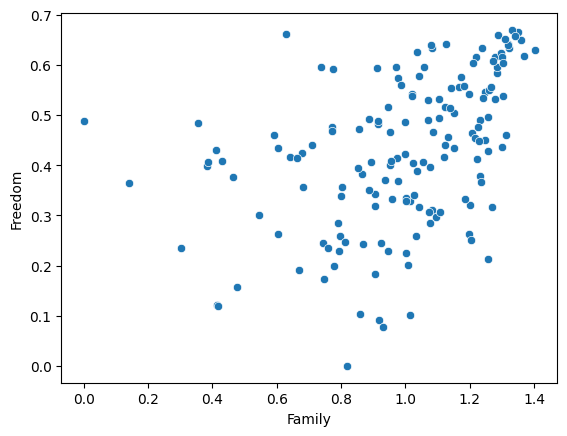

In [40]:
# Interactions

var1= input('Enter the name of the 1st variable ')
var2= input('Enter the name of the 2nd variable ')

if var1 not in df.columns or var2 not in df.columns:
    print(f"Error: not found in DataFrame!")
else:
    if is_numeric_dtype(df[var1]) and is_numeric_dtype(df[var2]):
        sns.scatterplot(data=df, x=df[var1], y=df[var2])
    else:
        print('Error: Datatypes mismatch')


Text(0.5, 1.0, 'Correlation Heatmap')

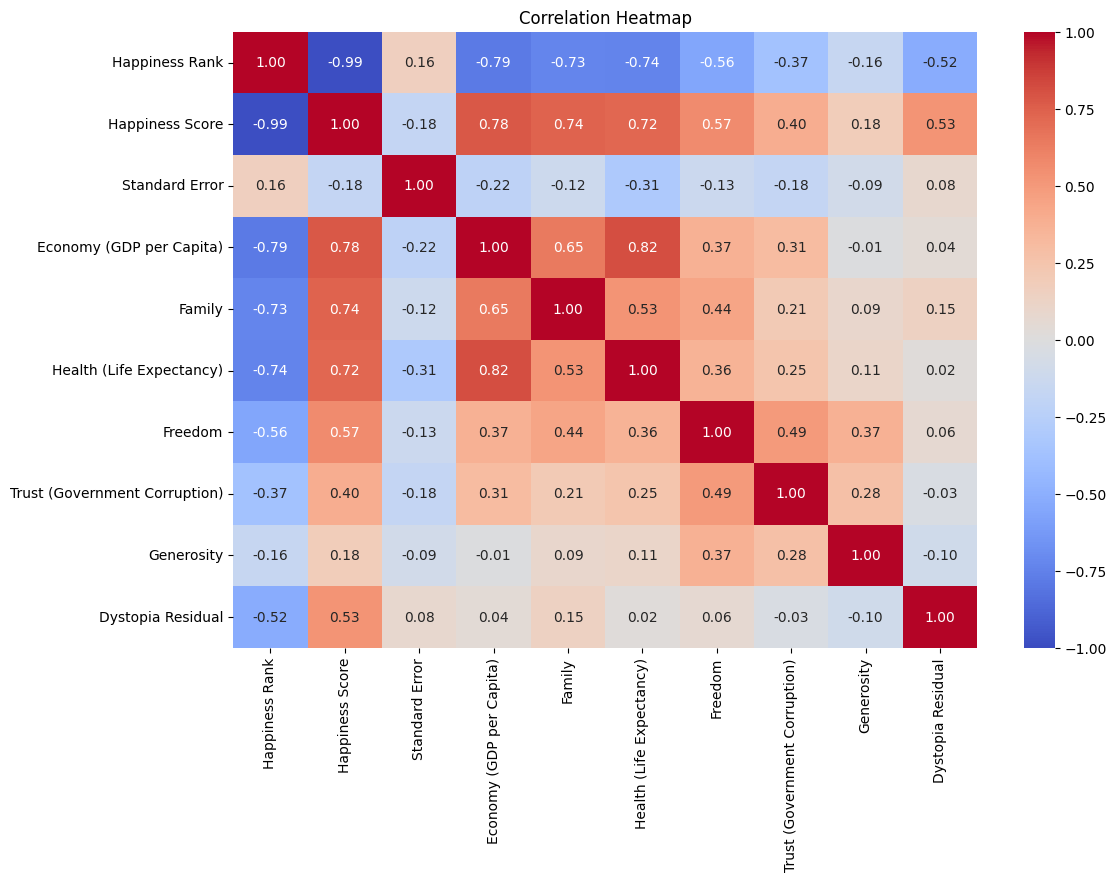

In [41]:
# Correlations
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")


In [43]:
# Sample

display(df.head(10))
display(df.tail(10))

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
5,Finland,Western Europe,6,7.406,0.03140,1.29025,1.31826,0.88911,0.64169,0.41372,0.23351,2.61955
6,Netherlands,Western Europe,7,7.378,0.02799,1.32944,1.28017,0.89284,0.61576,0.31814,0.47610,2.46570
7,Sweden,Western Europe,8,7.364,0.03157,1.33171,1.28907,0.91087,0.65980,0.43844,0.36262,2.37119
8,New Zealand,Australia and New Zealand,9,7.286,0.03371,1.25018,1.31967,0.90837,0.63938,0.42922,0.47501,2.26425
9,Australia,Australia and New Zealand,10,7.284,0.04083,1.33358,1.30923,0.93156,0.65124,0.35637,0.43562,2.26646


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
148,Chad,Sub-Saharan Africa,149,3.667,0.03830,0.34193,0.76062,0.15010,0.23501,0.05269,0.18386,1.94296
149,Guinea,Sub-Saharan Africa,150,3.656,0.03590,0.17417,0.46475,0.24009,0.37725,0.12139,0.28657,1.99172
150,Ivory Coast,Sub-Saharan Africa,151,3.655,0.05141,0.46534,0.77115,0.15185,0.46866,0.17922,0.20165,1.41723
151,Burkina Faso,Sub-Saharan Africa,152,3.587,0.04324,0.25812,0.85188,0.27125,0.39493,0.12832,0.21747,1.46494
152,Afghanistan,Southern Asia,153,3.575,0.03084,0.31982,0.30285,0.30335,0.23414,0.09719,0.36510,1.95210
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726


In [ ]:
# Insight 1: GDP is the strongest predictor of happiness. With a correlation coefficient of ~0.78, 
#            national wealth shows a near-linear relationship with citizen satisfaction.
# Insight 2: Regional Inequality is extreme. Western Europe and North America have a minimum 
#            happiness score higher than the average score of Sub-Saharan Africa and Southern Asia.
# Insight 3: Health and Wealth move together. The scatter plots show that countries with high GDP 
#            also possess high Life Expectancy (corr ~0.82), suggesting that happiness is a byproduct of infrastructure.
# Insight 4: Sub-Saharan Africa shows the highest internal variance. While it has the lowest average
#            scores, it has a wide range of outliers, unlike North America which is tightly clustered at the top.
# Insight 5: The "Freedom" threshold. Happiness scores rarely exceed 6.0 unless the "Freedom" score
#            is above 0.4, suggesting a baseline of personal liberty is required for high-tier satisfaction.